### Task 1: K-Means Clustering

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
wine = load_wine()

X = wine.data
y = wine.target

df_wine = pd.DataFrame(X, columns=wine.feature_names)

df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
inertias = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

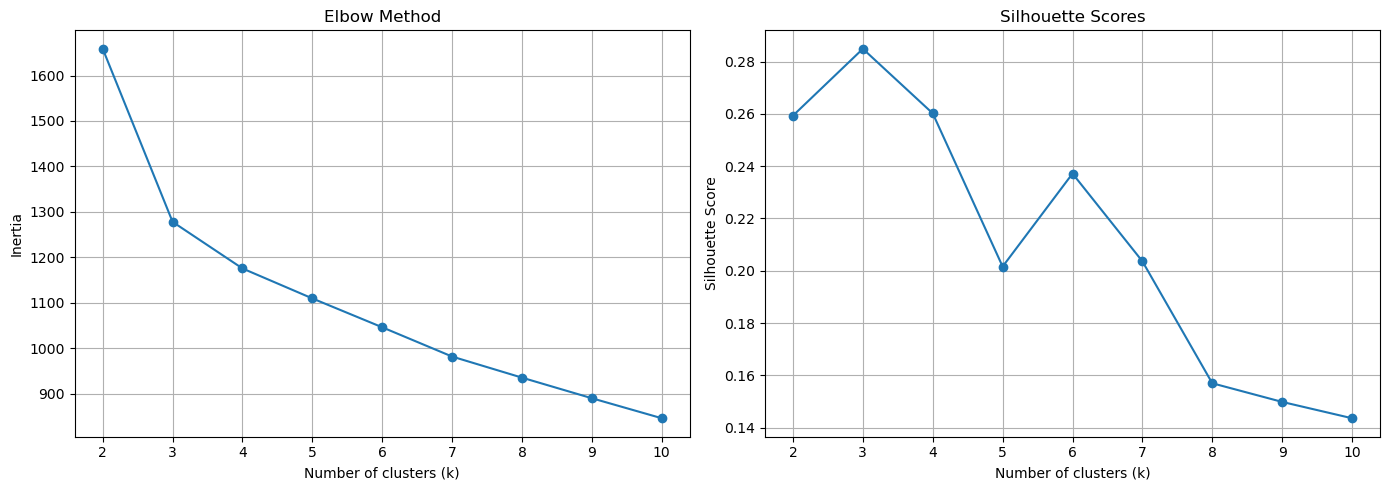

In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
optimal_k = 3

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

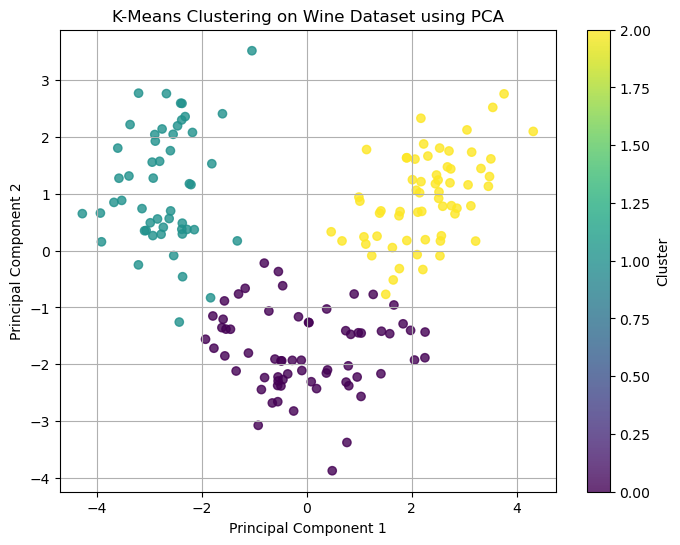

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    cmap="viridis",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on Wine Dataset using PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

Based on the elbow curve, the largest drop in inertia happens between k = 2 and k = 3. After k = 3, the inertia continues to decrease, but the improvement becomes smaller and more gradual. This suggests that k = 3 is a reasonable elbow point.

The silhouette score also supports this choice because the highest silhouette score is obtained when k = 3. This means that the clusters are more clearly separated at k = 3 compared to the other tested values.

Therefore, I selected k = 3 as the optimal number of clusters for the final K-Means model. The PCA scatter plot shows three mostly separated clusters. There is a small amount of overlap between some points, but overall the clustering result is coherent. This makes sense because the Wine dataset contains three original wine classes, although the K-Means model did not use these labels during training.

### Task 2: Hierarchical & Density-Based Clustering

In [9]:
optimal_k = 3

agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

print("Agglomerative cluster labels:")
print(agg_labels)

print("Agglomerative cluster sizes:")
print(np.bincount(agg_labels))

Agglomerative cluster labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 1 0 0 0 2 2 0 1 0 1 2 0 2
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Agglomerative cluster sizes:
[58 56 64]


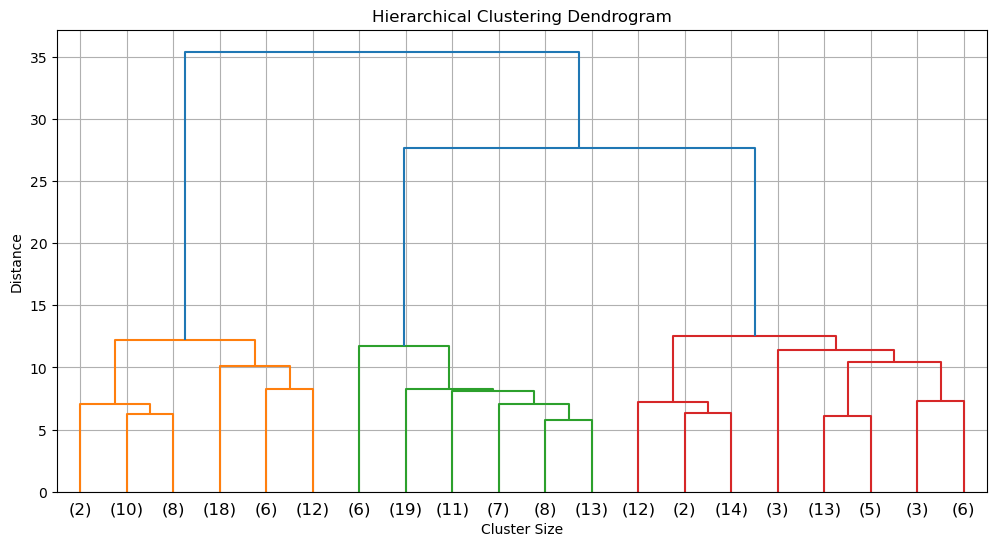

In [10]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=20)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [11]:
dbscan_configs = [
    {"eps": 1.5, "min_samples": 5},
    {"eps": 2.0, "min_samples": 5},
    {"eps": 2.5, "min_samples": 5},
    {"eps": 3.0, "min_samples": 5},
]

dbscan_results = []

for config in dbscan_configs:
    dbscan = DBSCAN(eps=config["eps"], min_samples=config["min_samples"])
    db_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    
    dbscan_results.append({
        "eps": config["eps"],
        "min_samples": config["min_samples"],
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "labels": db_labels
    })
    
    print(f"eps={config['eps']}, min_samples={config['min_samples']}")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print("-" * 40)

eps=1.5, min_samples=5
Number of clusters: 0
Number of noise points: 178
----------------------------------------
eps=2.0, min_samples=5
Number of clusters: 5
Number of noise points: 85
----------------------------------------
eps=2.5, min_samples=5
Number of clusters: 1
Number of noise points: 24
----------------------------------------
eps=3.0, min_samples=5
Number of clusters: 1
Number of noise points: 11
----------------------------------------


In [12]:
best_dbscan_result = min(
    dbscan_results,
    key=lambda result: abs(result["n_clusters"] - optimal_k)
)

best_dbscan_labels = best_dbscan_result["labels"]

print("Best DBSCAN configuration:")
print(f"eps = {best_dbscan_result['eps']}")
print(f"min_samples = {best_dbscan_result['min_samples']}")
print(f"Number of clusters = {best_dbscan_result['n_clusters']}")
print(f"Number of noise points = {best_dbscan_result['n_noise']}")

Best DBSCAN configuration:
eps = 2.0
min_samples = 5
Number of clusters = 5
Number of noise points = 85


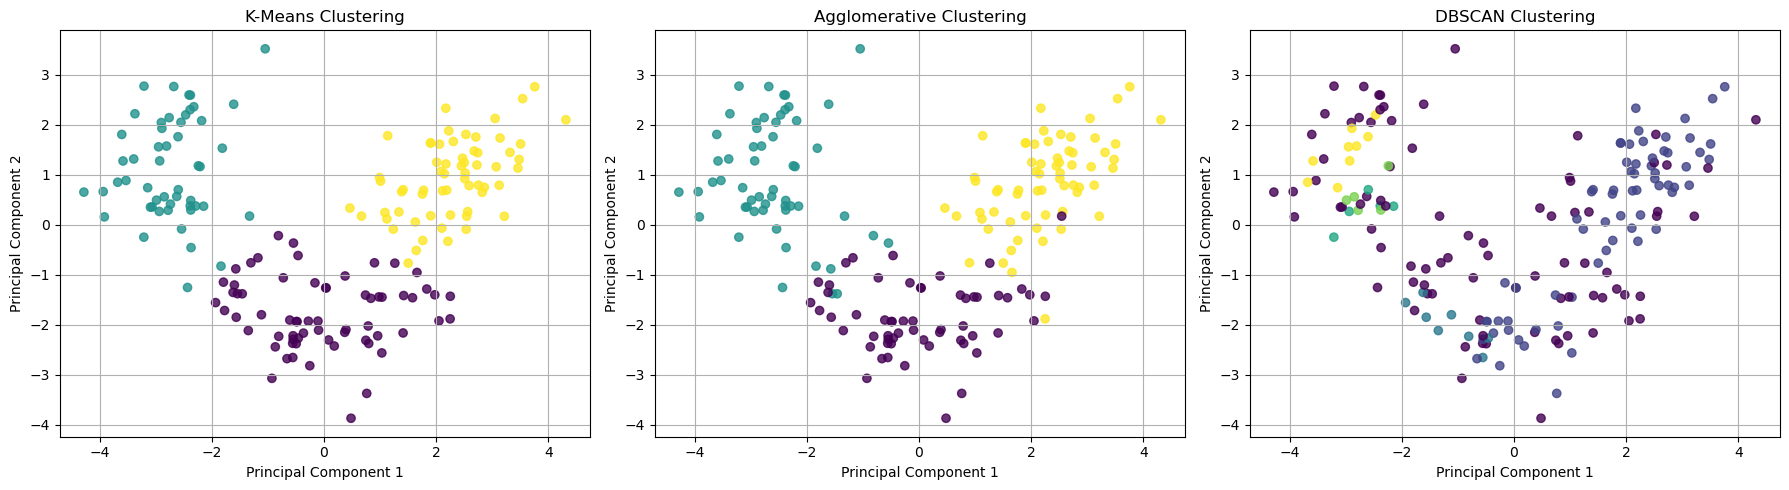

In [13]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap="viridis", alpha=0.8)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap="viridis", alpha=0.8)
plt.title("Agglomerative Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_labels, cmap="viridis", alpha=0.8)
plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.tight_layout()
plt.show()

In Task 2, I compared K-Means, Agglomerative Clustering, and DBSCAN on the same scaled Wine dataset. Agglomerative Clustering was applied with k = 3, using the same number of clusters selected in Task 1. The resulting cluster sizes were 58, 56, and 64, which shows that the algorithm divided the dataset into three fairly balanced groups.

The dendrogram also supports the presence of three main groups. In the dendrogram, the observations are first merged into smaller groups at lower distance values, and then these groups are combined into larger clusters at higher distance values. The large vertical jumps near the top of the dendrogram suggest that merging beyond three main groups would combine clusters that are already quite different from each other.

DBSCAN behaved differently from K-Means and Agglomerative Clustering. It was tested with four parameter combinations. With eps = 1.5 and min_samples = 5, DBSCAN found no clusters and marked all 178 samples as noise. With eps = 2.0 and min_samples = 5, it found 5 clusters but also marked 85 samples as noise. With eps = 2.5 and eps = 3.0, it found only 1 cluster, with 24 and 11 noise points respectively. Since none of the tested DBSCAN settings produced exactly 3 clusters, the configuration eps = 2.0 and min_samples = 5 was selected only because its cluster count was closest to the optimal k = 3 from Task 1.

The PCA comparison shows that K-Means and Agglomerative Clustering produced the most coherent results. Their three clusters are visually similar and mostly separated in the 2-D PCA projection. DBSCAN, however, produced a less stable result: many points were treated as noise or separated into smaller groups. This suggests that DBSCAN was more sensitive to parameter selection and less suitable for this Wine dataset in the tested configurations. Overall, K-Means and Agglomerative Clustering gave clearer and more interpretable clusters for this data.

### Task 3: Dimensionality Reduction Comparison

In [14]:
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [15]:
penguins_clean = penguins.dropna()

penguins_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [16]:
penguin_features = penguins_clean[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
]

penguin_species = penguins_clean["species"]

penguin_features.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [17]:
penguin_scaler = StandardScaler()
penguin_scaled = penguin_scaler.fit_transform(penguin_features)

In [18]:
pca_penguins = PCA(n_components=2)
penguins_pca = pca_penguins.fit_transform(penguin_scaled)

In [19]:
tsne_penguins = TSNE(n_components=2, random_state=42)
penguins_tsne = tsne_penguins.fit_transform(penguin_scaled)

In [20]:
mds_penguins = MDS(
    n_components=2,
    random_state=42,
    normalized_stress="auto",
    n_init=4
)

penguins_mds = mds_penguins.fit_transform(penguin_scaled)

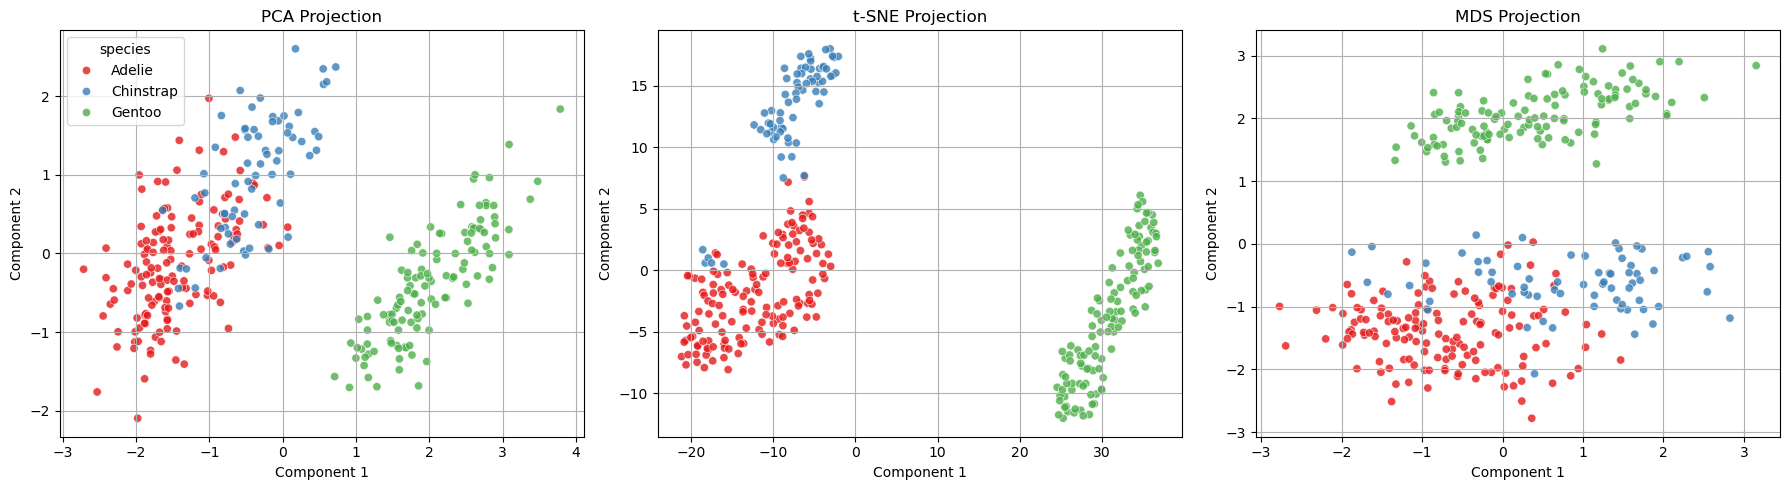

In [21]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=penguin_species,
    palette="Set1",
    alpha=0.8
)
plt.title("PCA Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)

plt.subplot(1, 3, 2)
sns.scatterplot(
    x=penguins_tsne[:, 0],
    y=penguins_tsne[:, 1],
    hue=penguin_species,
    palette="Set1",
    alpha=0.8,
    legend=False
)
plt.title("t-SNE Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)

plt.subplot(1, 3, 3)
sns.scatterplot(
    x=penguins_mds[:, 0],
    y=penguins_mds[:, 1],
    hue=penguin_species,
    palette="Set1",
    alpha=0.8,
    legend=False
)
plt.title("MDS Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)

plt.tight_layout()
plt.show()

In Task 3, I used the Palmer Penguins dataset to compare three dimensionality-reduction methods: PCA, t-SNE, and MDS. First, I loaded the dataset and observed that some rows contained missing values. These rows were removed using `dropna()` so that the algorithms could work without errors. Then I selected four numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`. These features were scaled before applying the dimensionality-reduction methods because their numeric ranges are different.

The PCA projection shows that the Gentoo species is clearly separated from the other two species. Adelie and Chinstrap are closer to each other and partially overlap, which means their measurements are more similar in the selected numeric features. Since PCA is a linear method, it gives an interpretable general view of the data, but it does not separate all three species perfectly.

The t-SNE projection gives the clearest visual separation. Gentoo is placed far away from the other species, and Chinstrap also forms a more distinct group compared to the PCA result. Adelie is still spread across a wider area, but the local grouping is easier to see. However, t-SNE mainly preserves local neighborhood structure, so the large distances between the groups should not be interpreted as exact real distances. The result can also look different on repeated runs if `random_state` is not fixed.

The MDS projection also separates Gentoo clearly from Adelie and Chinstrap. However, Adelie and Chinstrap overlap more in the lower part of the plot, so the separation is not as strong as in t-SNE. MDS tries to preserve pairwise distances between samples, which makes it useful for distance-based visualization, but in this output it does not separate the three species as clearly as t-SNE.

Overall, t-SNE produced the clearest visual separation of the three penguin species. PCA was useful for showing the main linear structure, and MDS gave a distance-preserving view. The strongest and most consistent pattern across all three methods is that Gentoo is clearly different from Adelie and Chinstrap, while Adelie and Chinstrap are more similar to each other and therefore overlap more.

### Task 4: Putting It Together

In [22]:
penguin_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
penguin_cluster_labels = penguin_kmeans.fit_predict(penguin_scaled)

print("K-Means cluster labels:")
print(penguin_cluster_labels[:20])

K-Means cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0]


In [23]:
true_species = penguin_species.values

In [24]:
ari_score = adjusted_rand_score(true_species, penguin_cluster_labels)
nmi_score = normalized_mutual_info_score(true_species, penguin_cluster_labels)

print(f"Adjusted Rand Index: {ari_score:.3f}")
print(f"Normalized Mutual Information: {nmi_score:.3f}")

Adjusted Rand Index: 0.799
Normalized Mutual Information: 0.790


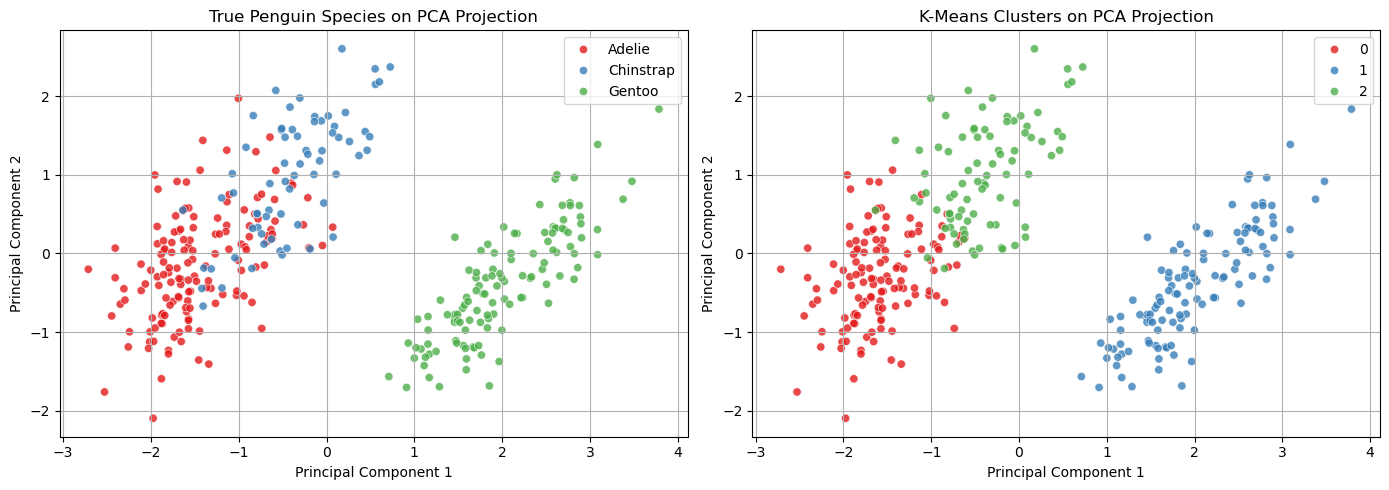

In [25]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=true_species,
    palette="Set1",
    alpha=0.8
)
plt.title("True Penguin Species on PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=penguins_pca[:, 0],
    y=penguins_pca[:, 1],
    hue=penguin_cluster_labels,
    palette="Set1",
    alpha=0.8
)
plt.title("K-Means Clusters on PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.tight_layout()
plt.show()

In Task 4, I applied K-Means clustering to the scaled numeric features of the Palmer Penguins dataset without using the `species` column during training. The model only used four measurements: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`. Since the dataset contains three known penguin species, I used `k = 3`.

The clustering result was evaluated against the true species labels using Adjusted Rand Index and Normalized Mutual Information. The Adjusted Rand Index was 0.799, and the Normalized Mutual Information score was 0.790. These values are fairly high, which means that the K-Means clusters were quite similar to the real species groups.

The PCA visualization also supports this result. In the true species plot, Gentoo penguins are clearly separated from the other two species. In the K-Means cluster plot, one cluster also captures this right-side Gentoo group very well. This shows that K-Means successfully discovered the most clearly separated species group without seeing the actual labels.

However, the model was not perfect. Adelie and Chinstrap overlap more in the PCA space, and their body measurements are more similar compared to Gentoo. Because of this, K-Means had more difficulty separating these two species completely. Some points near the border between Adelie and Chinstrap were grouped differently.

Overall, unsupervised learning partially rediscovered the real penguin species. It worked very well for Gentoo because that group has stronger numeric separation, especially in flipper length and body mass. It struggled more with Adelie and Chinstrap because their feature values overlap. This shows that unsupervised methods can be useful when natural groups exist in the data, but they cannot fully replace labeled data when classes are too similar.